# GAPS zonal closed-loop simulation demo
This Notebook simulates a GAPS closed-loop experiment with zonal control:
1. Only the DM is used for turbulence injection and wavefront correction (The PTT array is not used).
2. The PWFS controls the DM actuators (zonal reconstructor).
3. The HDFS operates in the baseline mode (i.e. monitoring segment ejections).
    - Segment piston is produced with a best-fit DM command.

- Released: 06/25/2025
- Written by: fquiros

In [1]:
import numpy as np

#----- Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Test definition
GAPS simulation tests are subclasses of the `gaps_simul` class. This parent class contains:
- The NGWS-P model (PWFS and HDFS models).
- The GAPS telescope simulator model (GMT pupil, DM and PTT array models).
- The atmospheric turbulence model.

The `gaps_simul` class contains all these models ready to use. A *test class* inherits from this class and defines the desired control topology. This Notebook shows how to use such a *test class* called `zonal_control_test`.

In [2]:
from zonal_control_test import zonal_control_test
import gaps_visulib as visu

/home/ubuntu/CEO/python/ceo/zemax


## GAPS models parameters
The parameters below are used to instantiate the child *test class* `zonal_control_test`.

NOTE: The wavefront sampling is **not** a free parameter. The simulation has been preconfigured to cope with the sampling needs for all models (PWFS, HDFS, DM, PTT array). The sampling parameters are:
- Array size in meters: 25.5 m (slightly larger than the GMT pupil).
- Array size in pixels: 460
- GMT pupil rotation: 15 deg

The following parameters cannot be changed after instantiation:

In [3]:
tick_time = 1e-3  # "tick" time of the simulation.
project_truss_onaxis = True  # Simulate truss shadow over central segment.

#---- MEMS parameters
mems_ref_ifunc_fname = 'MagAO-X_MEMS2k_ReferenceIF.npz' # name of IF model file
mems_grid_rot_deg = -2.5  # angle between DM grid and pupil [deg]

#--- Turbulence parameters
turb_type = 'Single Layer'
L0 = 25.0
single_layer_wind_speed = 13.5
single_layer_wind_direction = 0.0

The following parameters can be tuned up after instantiation:

In [4]:
#--- NGWS-P parameters
mag = 10.  # Star R-magnitude

#--- Pyramid WFS parameters
pyr_Ts = 1e-3     # PWFS integration time [s]
pyr_Td = 0.0      # Start of PWFS integration [s]
pyr_modulation = 2.0 # pyramid modulation in lambda/D units
pyr_RON = 0.5
pyr_emccd_gain = 600
pyr_ADU_gain = 1/30.

#--- HDFS parameters
hdfs_Ts = 150e-3  # HDFS integration time [s]
hdfs_Td = 50e-3  # Start of HDFS integration [s]
hdfs_fs_shape = 'round'  # Type of spatial filter: "none" or "round"
hdfs_fs_dim_mas = 50     # if "round", diameter of spatial filter in mas
hdfs_RON = 0.5
hdfs_emccd_gain = 10   # gain tuned for mag=10 to avoid detector saturation
hdfs_ADU_gain = 1/2.76
hdfs_darkCurrent = 0.

#--- Turbulence parameters
r0 = 20.0e-2  #really weak turbulence (only DM used to produce it)
project_to_mirror_space = True

## Instantiante GAPS Test Class

In [5]:
%%time
gaps = zonal_control_test(tick_time = tick_time,
                          project_truss_onaxis = project_truss_onaxis,
                          mag = mag, 
                          pyr_Ts = pyr_Ts, pyr_Td = pyr_Td,
                          pyr_modulation = pyr_modulation,
                          pyr_RON = pyr_RON,
                          pyr_emccd_gain = pyr_emccd_gain,
                          pyr_ADU_gain = pyr_ADU_gain,
                          hdfs_Ts = hdfs_Ts, hdfs_Td = hdfs_Td,
                          hdfs_fs_shape = hdfs_fs_shape, 
                          hdfs_fs_dim_mas = hdfs_fs_dim_mas,
                          hdfs_RON = hdfs_RON, 
                          hdfs_emccd_gain = hdfs_emccd_gain, 
                          hdfs_ADU_gain = hdfs_ADU_gain, 
                          hdfs_darkCurrent = hdfs_darkCurrent,
                          mems_ref_ifunc_fname = mems_ref_ifunc_fname,
                          mems_grid_rot_deg = mems_grid_rot_deg,
                          turb_type = turb_type, 
                          L0 = L0, r0 = r0,
                          single_layer_wind_speed = single_layer_wind_speed,
                          single_layer_wind_direction = single_layer_wind_direction,
                          project_to_mirror_space = project_to_mirror_space)

---> Initializing PWFS...
(@CEO)>Pyramid: Set modulation sampling to 24
Number of simulated PWFS GS photons [ph/s/m^2]: 2696629.2
Number of pixels across 25.5-m array: 460
---> Initializing HDFS...
Filename: /home/ubuntu/CEO/python/ceo/sensors/ngws_hdfs_phase_design_v2a_gaps.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  MASK          1 PrimaryHDU      12   (460, 460)   float64   
  1  PAIRS         1 ImageHDU         8   (2, 7)   int64   
  2  BASELINE      1 ImageHDU         7   (7,)   float64   
  3  ANGLE         1 ImageHDU         7   (7,)   float64   
  4  OFFSET        1 ImageHDU         7   (7,)   float64   
--> Initializing GMT pupil.....
--> Initializing MEMS model.....
Completed creation of influence function cube of size 460 x 460 x 2040.
--> Initializing PTT array model.....
Done! .....
Turbulence model: Single Layer
            r0 @ 500nm : 20.0 cm
        seeing @ 500nm : 0.50 arcsec
                    L0 : 25.0 m
       Mean wind speed : 13.5 m

## Calibrate NGWS-P wavefront sensors
Compute PWFS valid sub-apertures and reference vectors.

NOTE: These calibrations are always simulated in noise-free conditions.

In [6]:
gaps.calibrate_sensors()

--> Calibrating PWFS....
Center of subpupil images (pix):
[[117.5 117.5]
 [117.5 249.5]
 [249.5 117.5]
 [249.5 249.5]]
->     Number of valid SAs: 5370
--> Calibrating HDFS....
HDFS total flux should be equal to one, but we get: 0.4399
@(CEO)>imaging: Device memory allocation
@(CEO)>imaging: Creating a 2D FFT plan
@(CEO)> Setting up random generator

@(CEO)>imaging:
 . imaging device    :    1
 . pupil sampling    :  460
 . DFT sampling      : 1840
 . imagelet sampling : 1840
 . frame sampling    :  368
 . source #          :    1
----------------------------------------------------

@(CEO)>sources:
 zen[arcsec] azim[deg]  height[m]  lambda[micron] magnitude
  0.00        0.00         inf       0.760    10.0
 wavefront pixel sampling: 211600
@(CEO)>mask: nnz = 211600 (density: 1.00) 
----------------------------------------------------

@(CEO)>sources:
 zen[arcsec] azim[deg]  height[m]  lambda[micron] magnitude
  0.00        0.00         inf       0.810    10.0
 wavefront pixel samplin

### PWFS valid sub-apertures

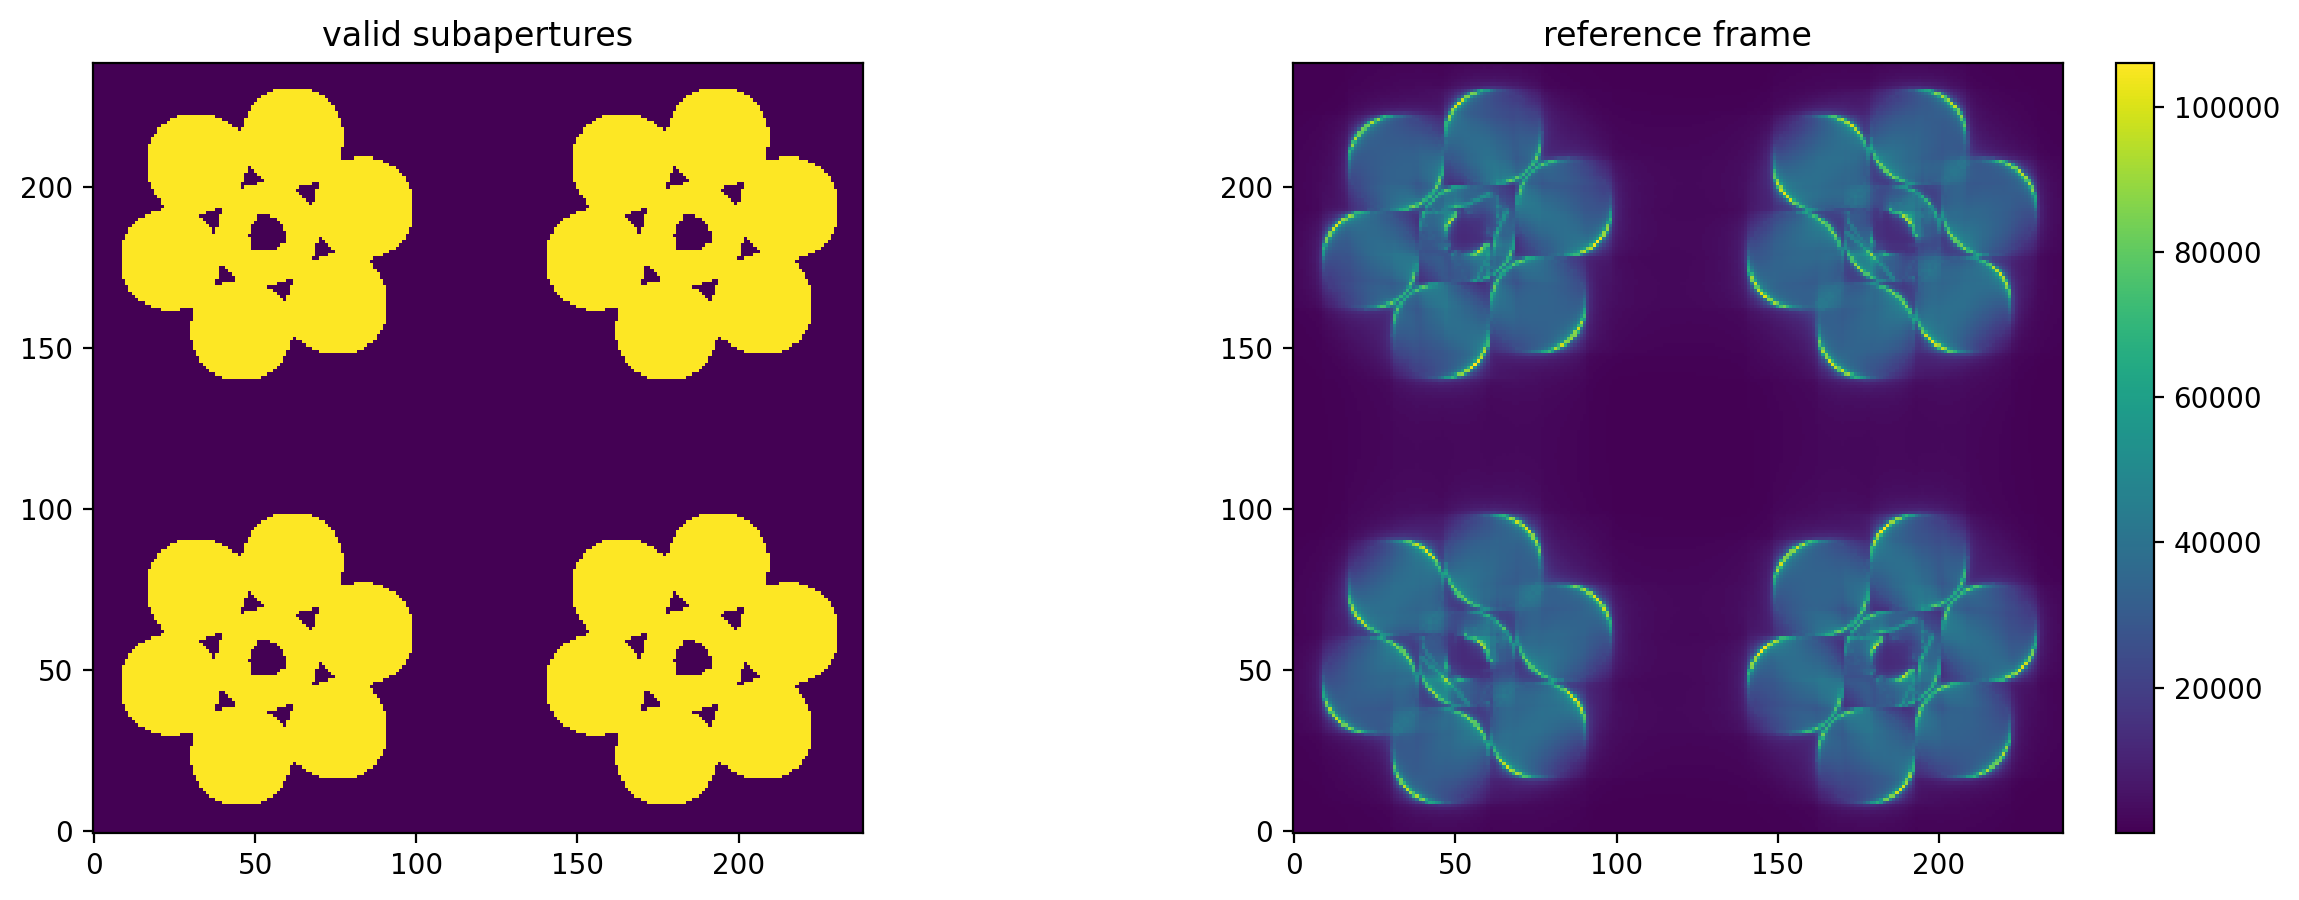

In [7]:
pyr_validpix = np.sum(gaps.pwfs.indpup, axis=0, dtype='bool')
extr = gaps.pwfs._extr

#xvalidpix, yvalidpix = np.where(pyr_validpix)
#pyr_validSAidx = wfs.get_subpupil(0, this_frame=wfs.indpup[0])

fig, (ax1,ax2) = plt.subplots(ncols=2)
fig.set_size_inches(15,5)
fig.dpi=200
imm1 = ax1.imshow(pyr_validpix[extr:-1-extr, extr:-1-extr], origin='lower')
ax1.set_title('valid subapertures')
imm2 = ax2.imshow(gaps.pwfs.ccd_frame, origin='lower')
ax2.set_title('reference frame')
fig.colorbar(imm2, ax=ax2);

### PWFS reference slope vector

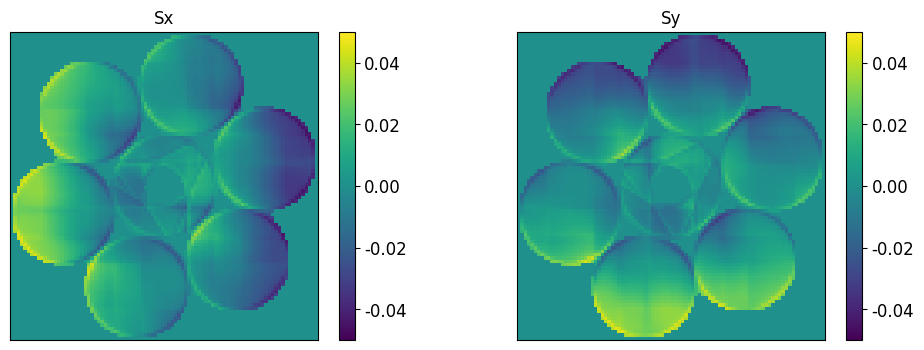

In [8]:
(sx_ref_2d,sy_ref_2d) = visu.pyr_display_signals(gaps.pwfs,
                        *gaps.pwfs.get_ref_measurement(out_format='list'), clim_step=0.05)

### HDFS reference fringes and measurement vector

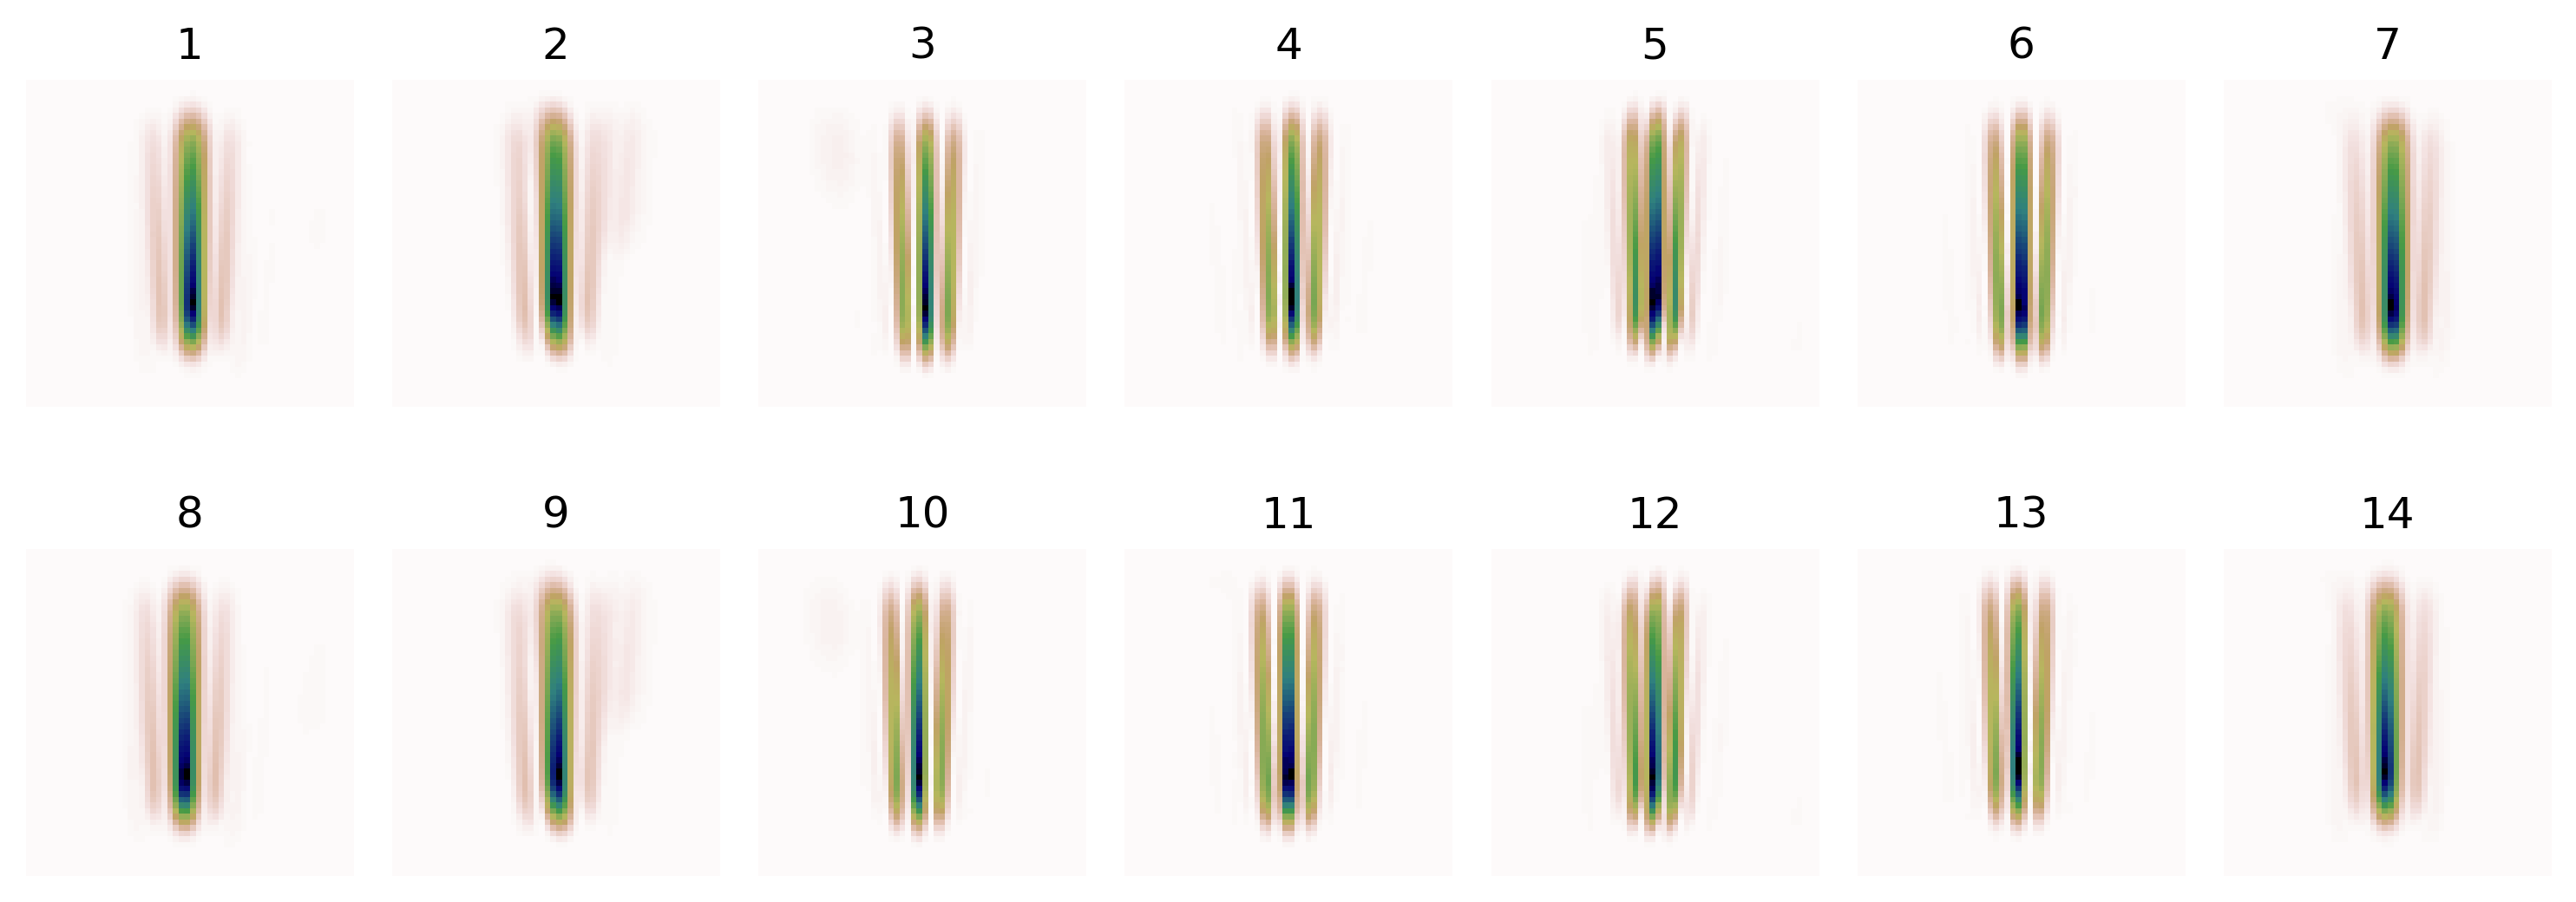

In [9]:
visu.hdfs_show_fringes(gaps.hdfs)

In [10]:
print("HDFS reference vector:")
print(np.array_str(gaps.hdfs.get_ref_measurement()))

HDFS reference vector:
[28.99660299 28.95341231 29.00107279 29.00066792 29.1032236  28.99932197
 28.99982501 28.99639364 28.95449907 29.00119648 29.00084874 29.10059432
 28.99947269 28.9996723 ]


# Zonal Control Demo
The *test class* (in this case `zonal_control_test`) must implement one single method called **configure()**. This method produces all needed system calibrations, and defines the control topology.

In [11]:
%%time
pure_delay = 1 # number of frames
gaps.configure(pure_delay=pure_delay)

Zonal calibration between DM and PWFS in progress....
Restoring data from file: ZONAL_PYR_DM_mod2.0_vact_thr_0.40_gridrot_-2.50.npz
Starting SVD analysis
LS reconstructor with 1 eigenmodes filtered.
HDFS calibration of DM best-fit segment piston in progress...
Starting calibration of interaction matrix
0 1 2 3 4 5 6 
Computing HDFS Reconstructor...
CPU times: user 8min 6s, sys: 47.2 s, total: 8min 53s
Wall time: 1min 36s


## Calibration Repository
Calibration data is stored in a dictionary called `calib_repo`. For this test, two calibration sets were calibrated:
1. Zonal DM - PWFS calibration data
2. Segment piston - HDFS calibration data

In [12]:
gaps.calib_repo['zonal-dm-pwfs'].keys()

dict_keys(['intmat', 'sv', 'wf_last_eigenmode', 'svd_thr', 'recmat'])

In [13]:
gaps.calib_repo['spp-hdfs'].keys()

dict_keys(['Pp2m', 'intmat', 'sv', 'reg_sv', 'wf_last_eigenmode', 'reg_factor', 'recmat'])

### Retrieve valid actuators

In [14]:
validacts = gaps.dm_valid_acts_params['dm_valid_acts']
ifpeak2D = gaps.tel.mems2k.get_comm_2D(gaps.dm_valid_acts_params['ifpeak'])
actvec = np.zeros(gaps.tel.mems2k.n_acts)
actvec[validacts] = 1
actvec2D = gaps.tel.mems2k.get_comm_2D(actvec)
nvacts = len(validacts)
print("Number of valid DM actuators: %d"%nvacts)

Number of valid DM actuators: 1526


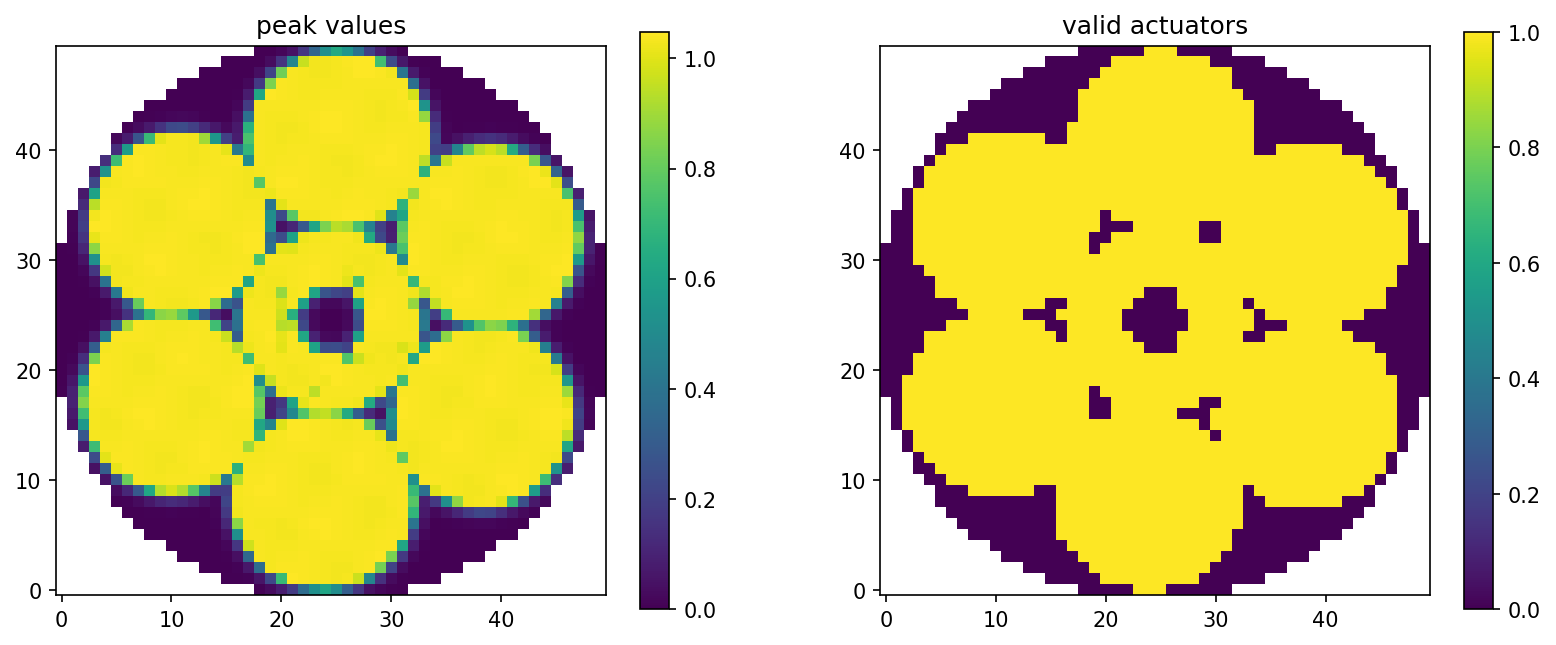

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2)
fig.set_size_inches((13,5))
fig.dpi = 150

im1 = ax1.imshow(ifpeak2D, origin='lower')
clb1 = fig.colorbar(im1, ax=ax1)
ax1.set_title('peak values')

im2 = ax2.imshow(actvec2D, origin='lower')
clb2 = fig.colorbar(im2, ax=ax2)
ax2.set_title('valid actuators');

### Check DM-PWFS Interaction Matrix and SVD

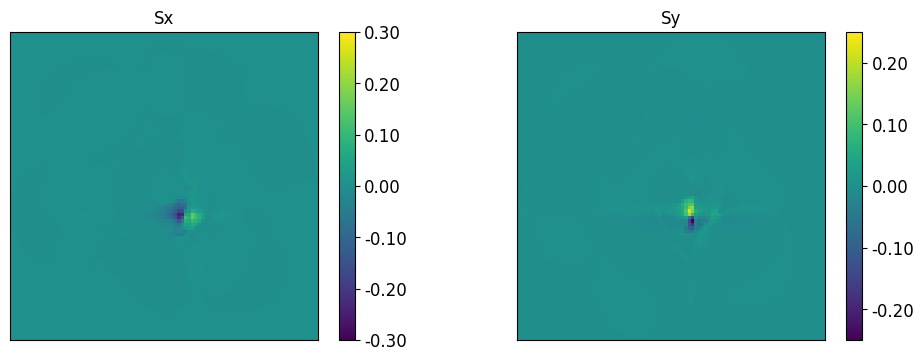

In [16]:
#------ Show signal in intmat
# the hump: [647, 648, 696, 697]
idx = 641
visu.pyr_display_signals(gaps.pwfs, np.squeeze(gaps.calib_repo['zonal-dm-pwfs']['intmat'][0:gaps.pwfs.n_sspp,idx]*100e-9), 
                    np.squeeze(gaps.calib_repo['zonal-dm-pwfs']['intmat'][gaps.pwfs.n_sspp:,idx]*100e-9), clim_step=0.05);

The last eigenmode corresponding to "global piston" is filtered out.

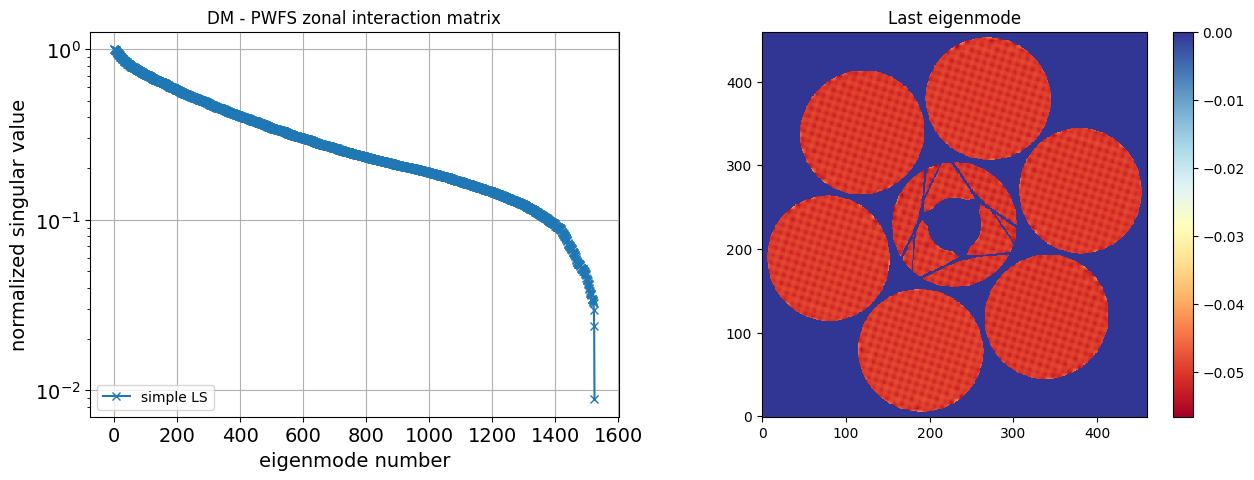

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2)
fig.set_size_inches(15,5)
fig.dpi=100

ss1 = gaps.calib_repo['zonal-dm-pwfs']['sv']
ax1.semilogy(ss1/np.max(ss1), 'x-', label='simple LS')
ax1.legend(loc = 'lower left')
ax1.grid()
ax1.tick_params(labelsize=14)
ax1.set_xlabel('eigenmode number', fontsize=14)
ax1.set_ylabel('normalized singular value', fontsize=14)
ax1.set_title('DM - PWFS zonal interaction matrix')

wf_dm = gaps.calib_repo['zonal-dm-pwfs']['wf_last_eigenmode']
imm = ax2.imshow(wf_dm, interpolation='None',cmap='RdYlBu',origin='lower')
ax2.set_title('Last eigenmode')
clb = fig.colorbar(imm, ax=ax2)#, fraction=0.012, pad=0.03,format="%.1f")
#clb.set_label('m WF', fontsize=12)

### Check DM best-fit segment piston - HDFS Interaction Matrix and SVD

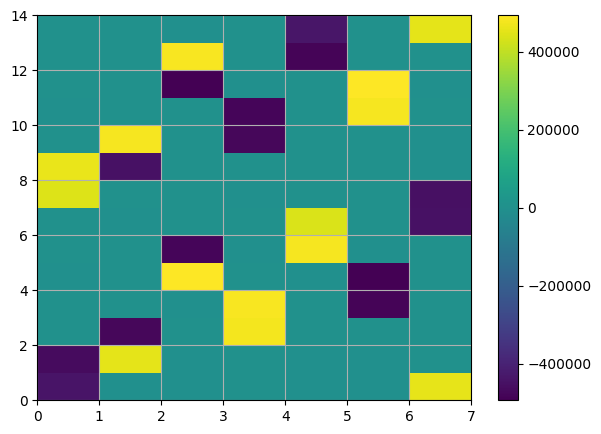

In [18]:
fig, ax1 = plt.subplots()
fig.set_size_inches(7,5)
imm = ax1.pcolor(gaps.calib_repo['spp-hdfs']['intmat'])
ax1.grid()
fig.colorbar(imm, ax=ax1)#, fraction=0.012) 

For the HDFS reconstructor, rather than filtering out the last eigenmode, a regularized LS reconstructor penalizing global piston is preferred.

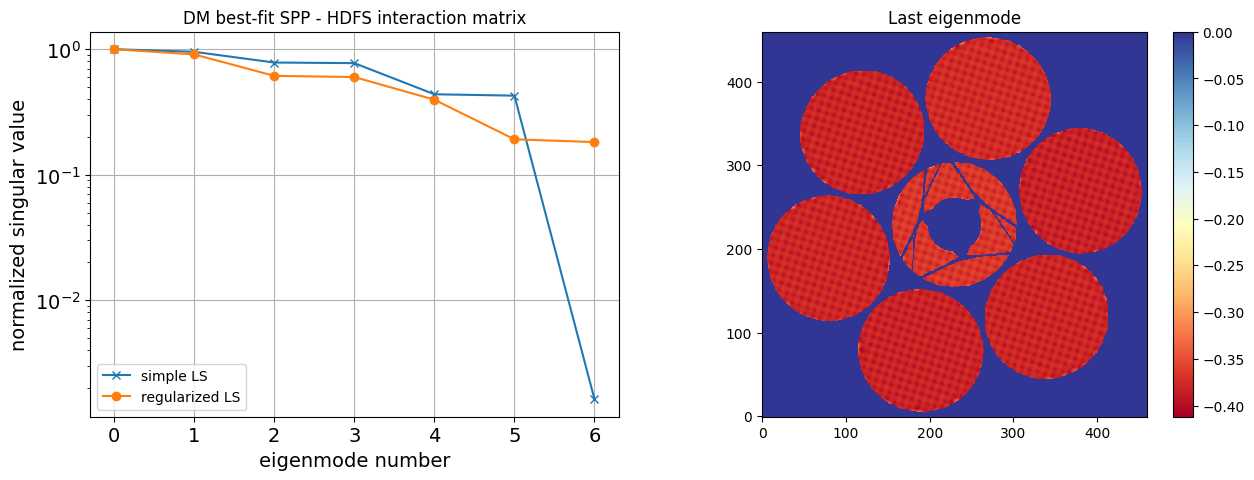

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2)
fig.set_size_inches(15,5)
fig.dpi=100

ss1 = gaps.calib_repo['spp-hdfs']['sv']
ss2 = gaps.calib_repo['spp-hdfs']['reg_sv']
ax1.semilogy(ss1/np.max(ss1), 'x-', label='simple LS')
ax1.semilogy(ss2/np.max(ss2), 'o-', label='regularized LS')
ax1.legend(loc = 'lower left')
ax1.grid()
ax1.tick_params(labelsize=14)
ax1.set_xlabel('eigenmode number', fontsize=14)
ax1.set_ylabel('normalized singular value', fontsize=14)
ax1.set_title('DM best-fit SPP - HDFS interaction matrix')

wf_dm = gaps.calib_repo['spp-hdfs']['wf_last_eigenmode']
imm = ax2.imshow(wf_dm, interpolation='None',cmap='RdYlBu',origin='lower')
ax2.set_title('Last eigenmode')
clb = fig.colorbar(imm, ax=ax2)#, fraction=0.012, pad=0.03,format="%.1f")
#clb.set_label('m WF', fontsize=12)

## Simulation Case 1: No turbulence + initial offset

Before launching a simulation you can always change some of the parameters:

Without turbulence there is no need for the HDFS to integrate 150 ms (baseline integration time). We can make it shorter to speed up convergence.

In [42]:
#----- Change HDFS timing parameters

hdfs_T_out = 0.050 # in seconds
hdfs_T_d = 0.0 # <-- set the start time of the HDFS to 0.0 if you want to visualize HDFS frames during bootstrap
wait_n_frames = 1
gaps.update_hdfs_rate(hdfs_T_out, hdfs_T_d, ctrl_wait_n_frames=wait_n_frames)

Introduce an initial random offset. Test different RMS values for the initial scramble.

In [43]:
gaps.wf_ctrl.reset_offset()
#gaps.wf_ctrl.set_scramble(do_piston=True, piston_rms=400e-9)  #<-- Introduce a segment piston with the PTT array, even though it is not used in the control loop.
gaps.wf_ctrl.set_scramble(do_dm_acts=True, dm_acts_rms=1e-6)   #<-- Zonal DM scramble

Launch the closed-loop simulation, sit back and relax. Note that if the DM scramble is large enough, there will be some segment ejections! You may even start to see **island** ejections...

In [44]:
#-- Turn on/off turbulence and WFS noise
gaps.simul_turb(False)
gaps.simul_noise(True)
liveShow = False

res = gaps.runClosedLoop(totSimulTime=210e-3, liveShow=liveShow)

 iter: 99/210, ET: 0.105 s, on-axis WF RMS [nm]: 387.5
HDFS recovering segment piston!
 iter: 210/210, ET: 0.105 s, on-axis WF RMS [nm]: 19.07

### Visualize telemetry

The `runClosedLoop` method returns a dictionary with the simulation results. Below are some example of telemetry plots.

In [45]:
res.keys()

dict_keys(['tur_wfe', 'wfe', 'seg_wfe', 'spp', 'time_vec', 'wf_res', 'pwfs_meas', 'pwfs_meas_rms', 'hdfs_meas', 'hdfs_fringes', 'hdfs_time_vec', 'hdfs_ctrl_command', 'hdfs_ctrl_time_vec', 'ao_delta_command', 'ao_integr_command'])

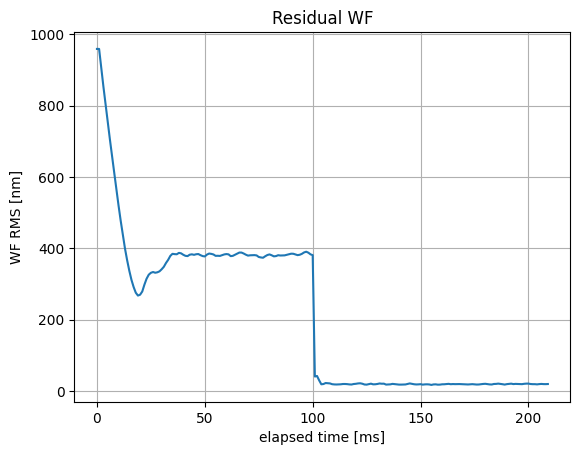

In [46]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['wfe'])*1e9)
plt.xlabel('elapsed time [ms]')
plt.ylabel('WF RMS [nm]')
plt.title('Residual WF')
plt.grid()

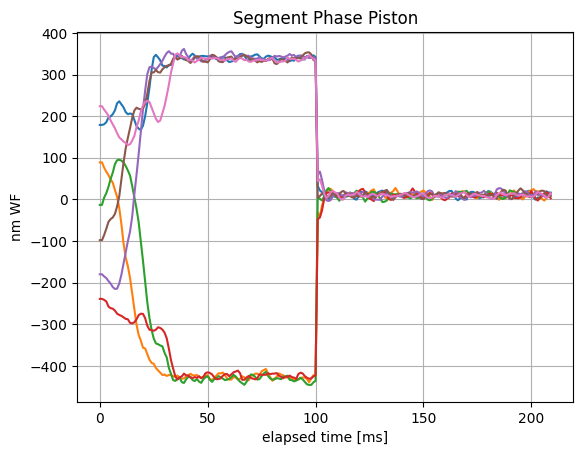

In [47]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['spp'])*1e9)
plt.xlabel('elapsed time [ms]')
plt.ylabel('nm WF')
plt.title('Segment Phase Piston')
plt.grid()

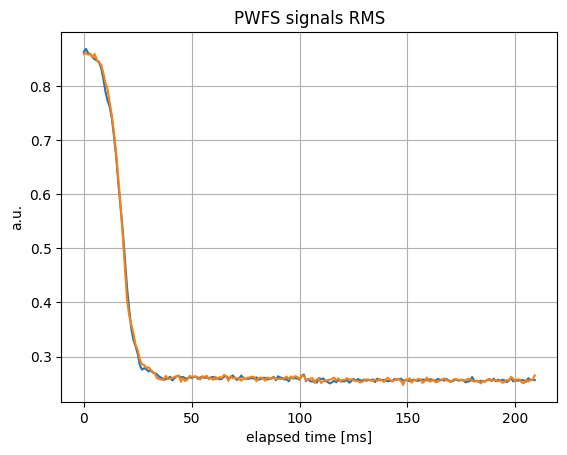

In [48]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['pwfs_meas_rms']))
plt.xlabel('elapsed time [ms]')
plt.ylabel('a.u.')
plt.title('PWFS signals RMS')
plt.grid()

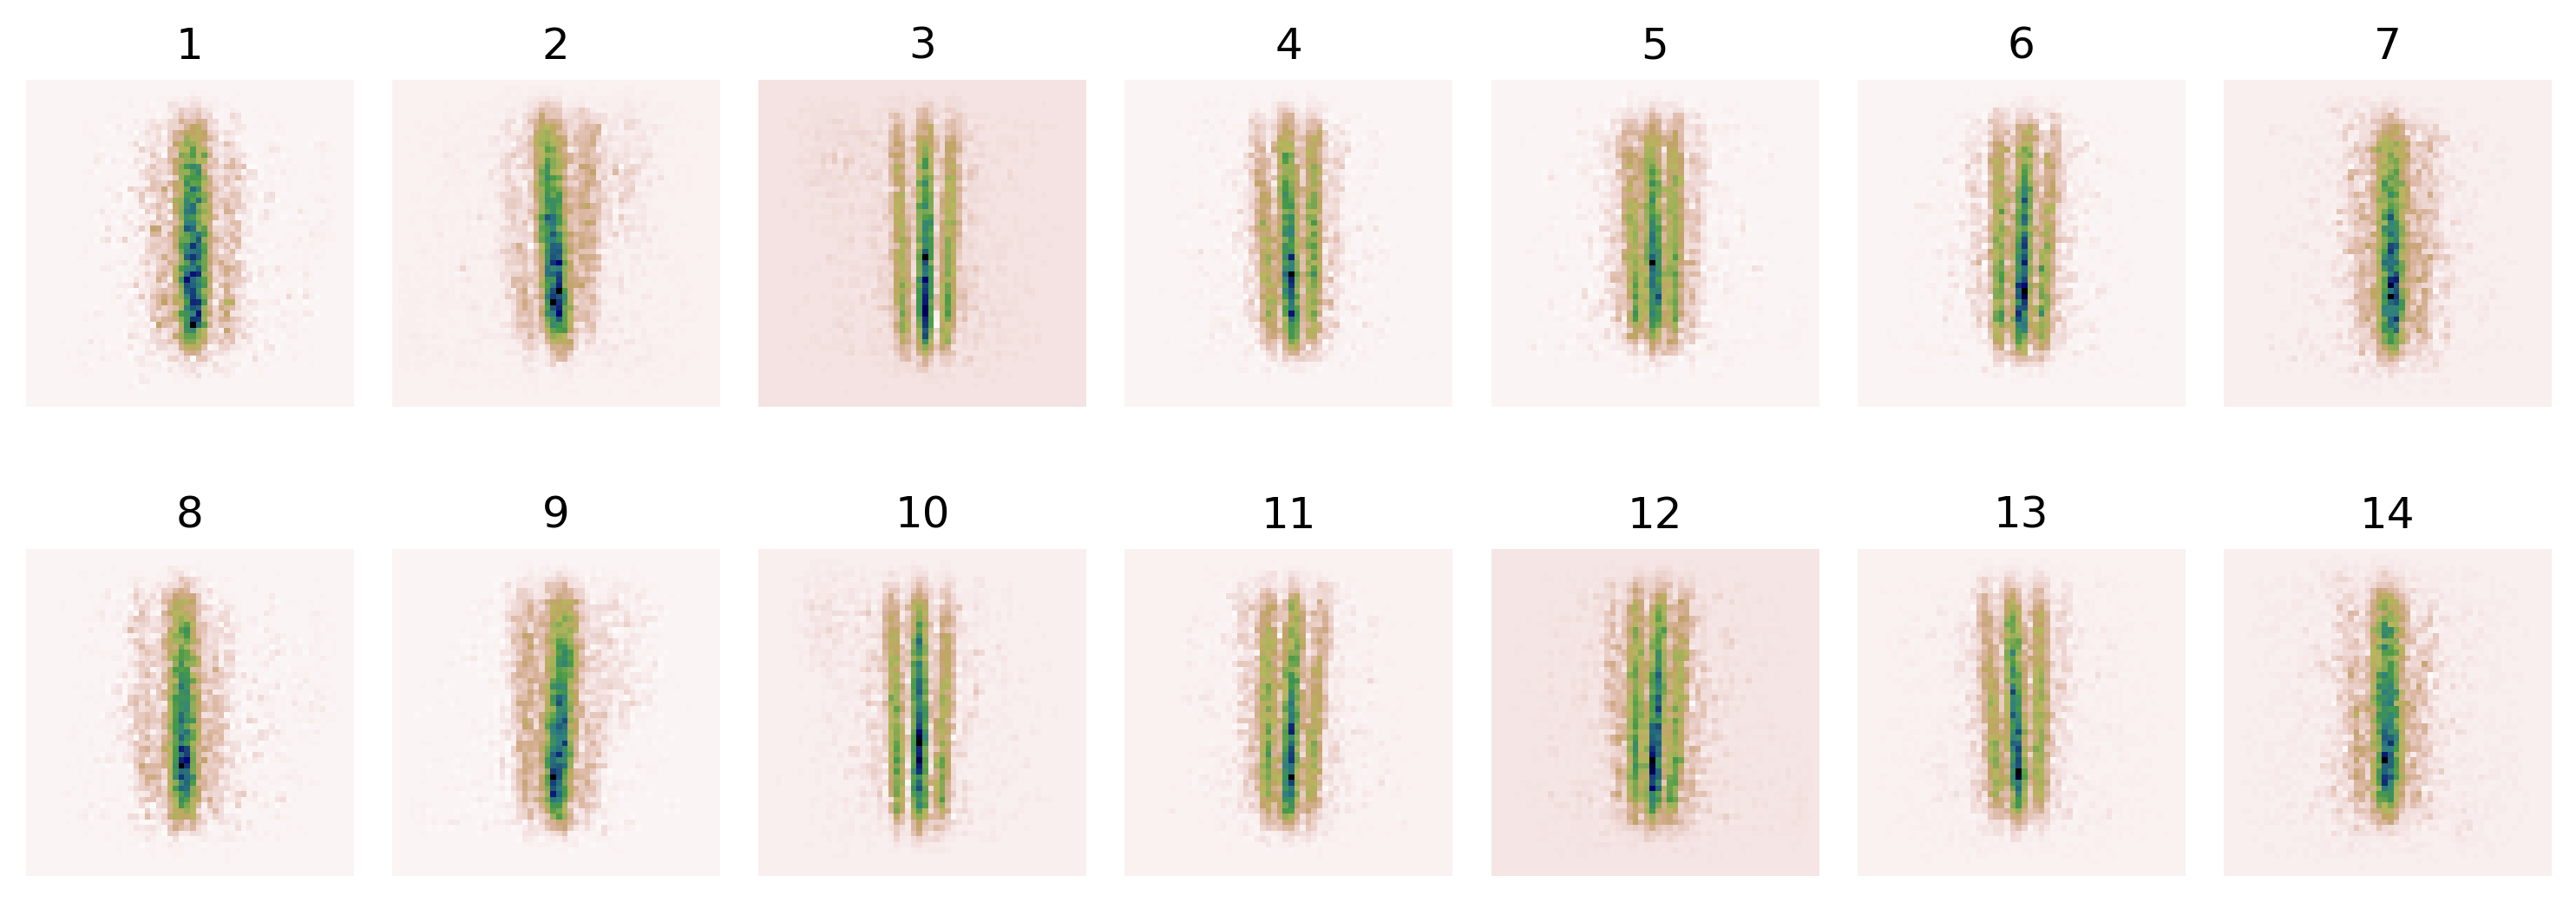

In [49]:
#-- First integrated fringes
this_iter = 0
fringes = res['hdfs_fringes'][this_iter]
visu.hdfs_show_fringes(gaps.hdfs, fringes=fringes)

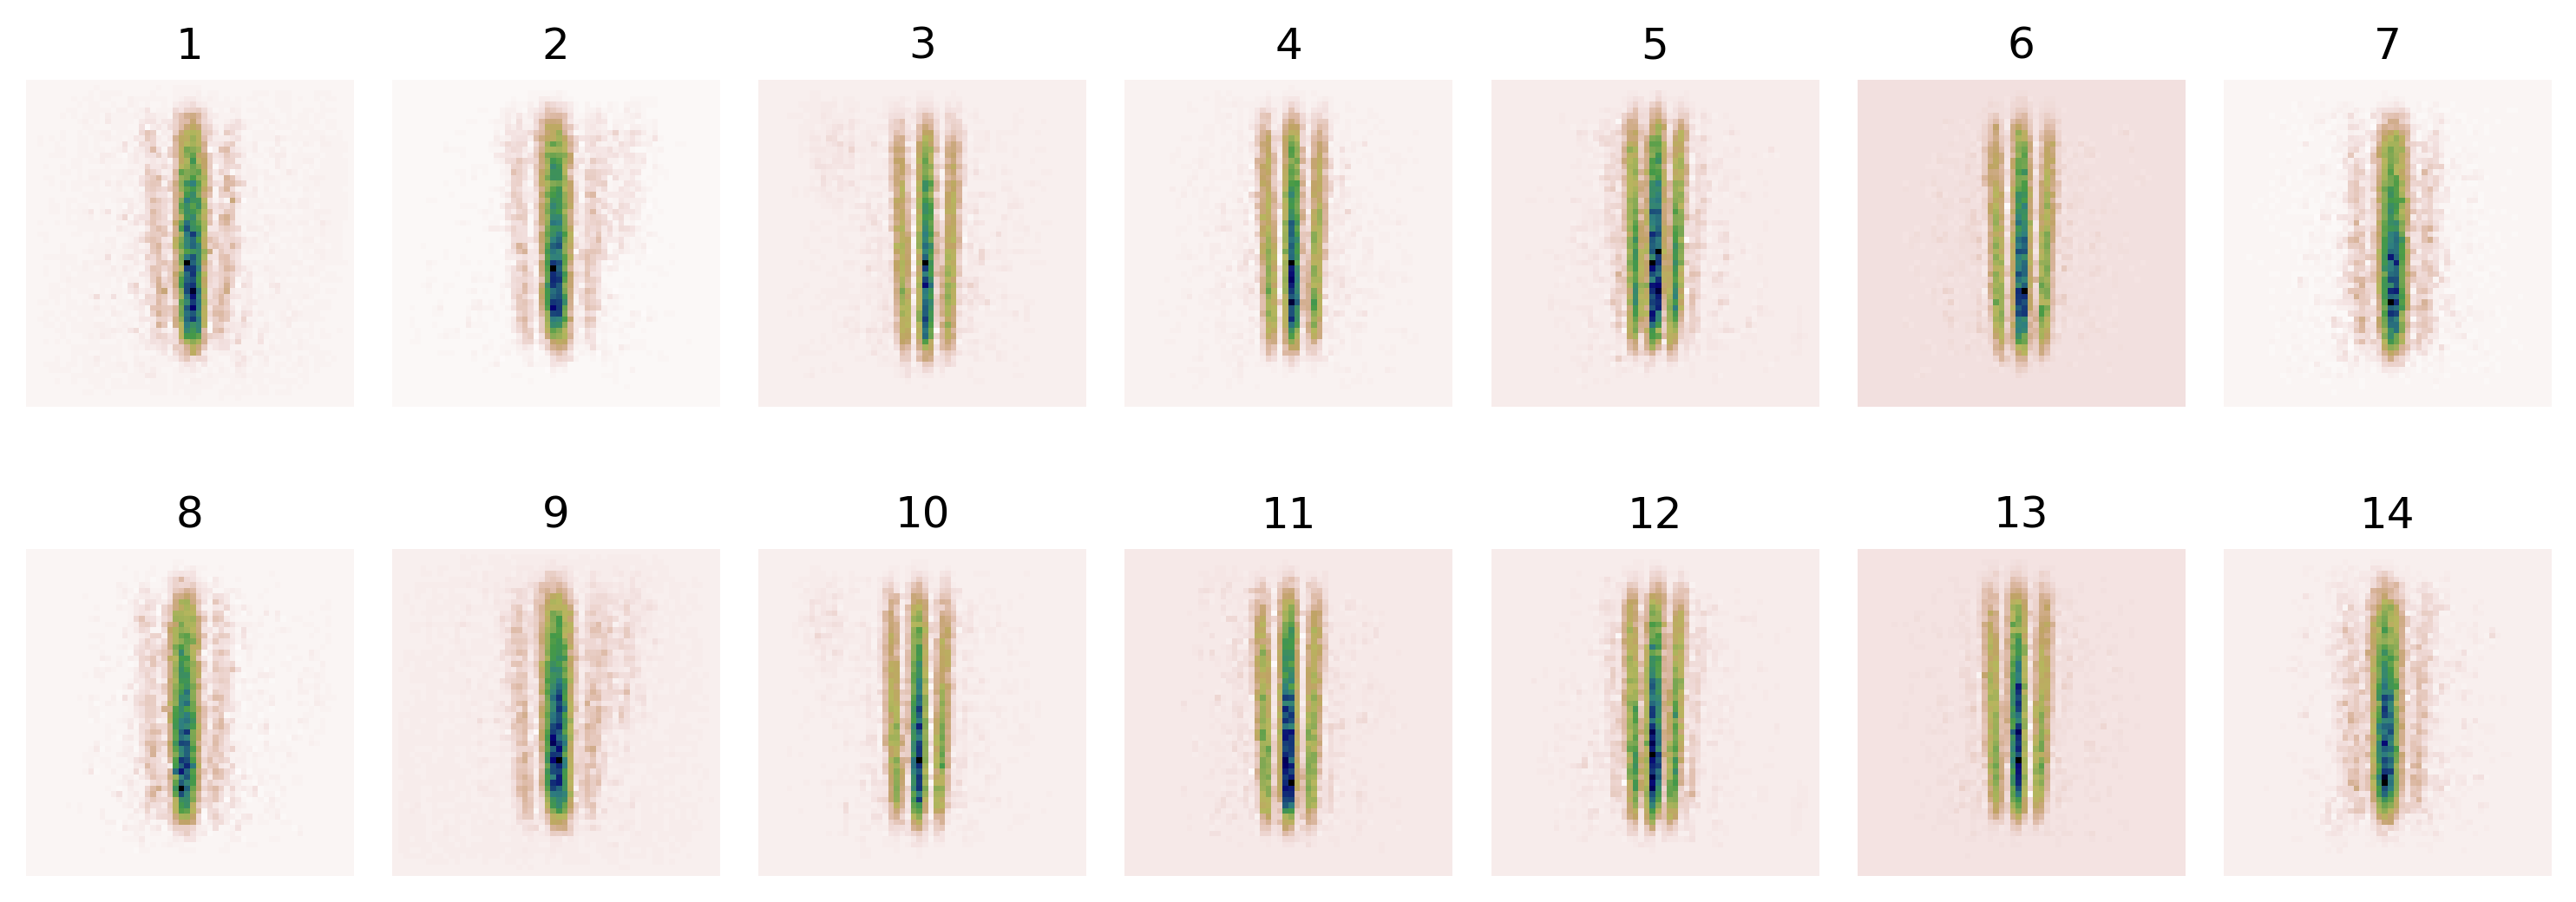

In [50]:
#-- Last integrated fringes
this_iter = -1
fringes = res['hdfs_fringes'][this_iter]
visu.hdfs_show_fringes(gaps.hdfs, fringes=fringes)

## Simulation Case 2: With mild turbulence
Remember we are using only the DM (not the PTT array). Therefore, we cannot inject bad seeing conditions.

In [51]:
#----- Change HDFS timing parameters

hdfs_T_out = 0.150 # in seconds
hdfs_T_d = 0.0 # <-- set the start time of the HDFS to 0.0 if you want to visualize HDFS frames during bootstrap
wait_n_frames = 1
gaps.update_hdfs_rate(hdfs_T_out, hdfs_T_d, ctrl_wait_n_frames=wait_n_frames)

Adjust turbulence parameters:

In [52]:
print('Fried parameter: %0.1f cm'%(gaps.atm.r0*1e2))
gaps.atm.project_to_mirror_space = True

Fried parameter: 20.0 cm


In [53]:
gaps.wf_ctrl.reset_offset()
gaps.simul_turb(True)
gaps.simul_noise(True)
liveShow = False

res = gaps.runClosedLoop(totSimulTime=500e-3, liveShow=liveShow)

 iter: 349/500, ET: 0.115 s, on-axis WF RMS [nm]: 328.2
HDFS recovering segment piston!
 iter: 500/500, ET: 0.176 s, on-axis WF RMS [nm]: 26.55

### Visualize telemetry

The `runClosedLoop` method returns a dictionary with the simulation results. Below are some example of telemetry plots.

In [60]:
res.keys()

dict_keys(['tur_wfe', 'wfe', 'seg_wfe', 'spp', 'time_vec', 'wf_res', 'pwfs_meas', 'pwfs_meas_rms', 'hdfs_meas', 'hdfs_fringes', 'hdfs_time_vec', 'hdfs_ctrl_command', 'hdfs_ctrl_time_vec', 'ao_delta_command', 'ao_integr_command'])

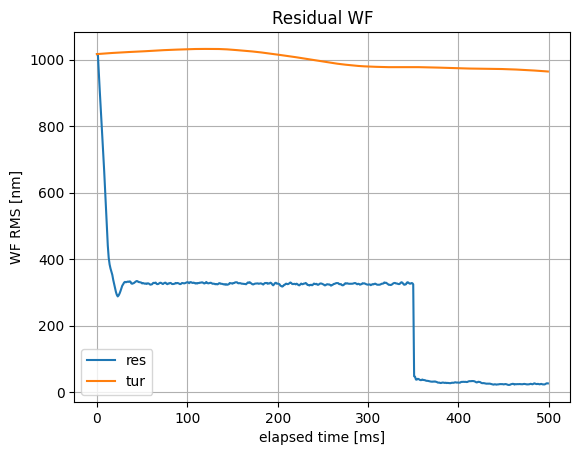

In [61]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['wfe'])*1e9, label='res')
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['tur_wfe'])*1e9, label='tur')
plt.xlabel('elapsed time [ms]')
plt.ylabel('WF RMS [nm]')
plt.title('Residual WF')
plt.grid()
plt.legend()

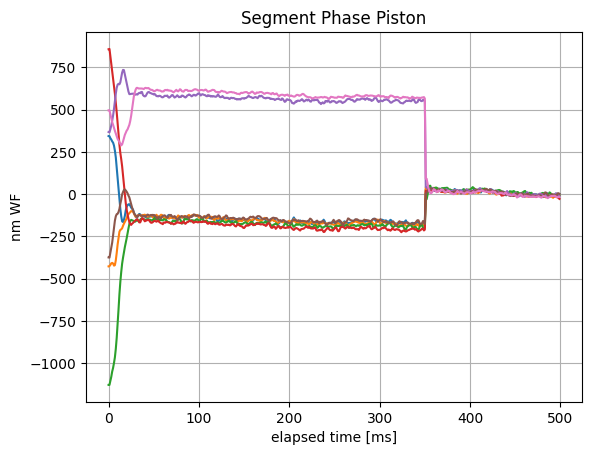

In [62]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['spp'])*1e9)
plt.xlabel('elapsed time [ms]')
plt.ylabel('nm WF')
plt.title('Segment Phase Piston')
plt.grid()

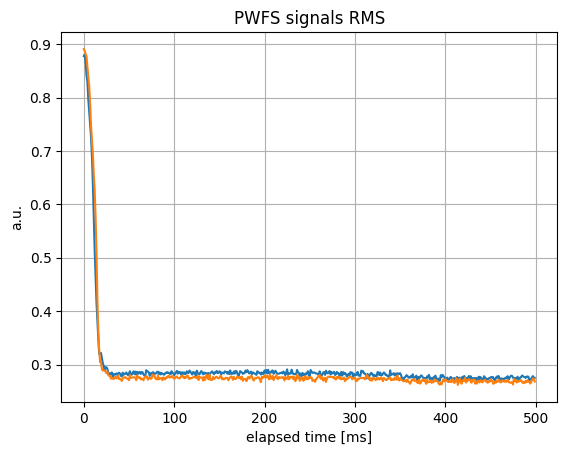

In [63]:
plt.plot(np.array(res['time_vec'])*1e3, np.array(res['pwfs_meas_rms']))
plt.xlabel('elapsed time [ms]')
plt.ylabel('a.u.')
plt.title('PWFS signals RMS')
plt.grid()

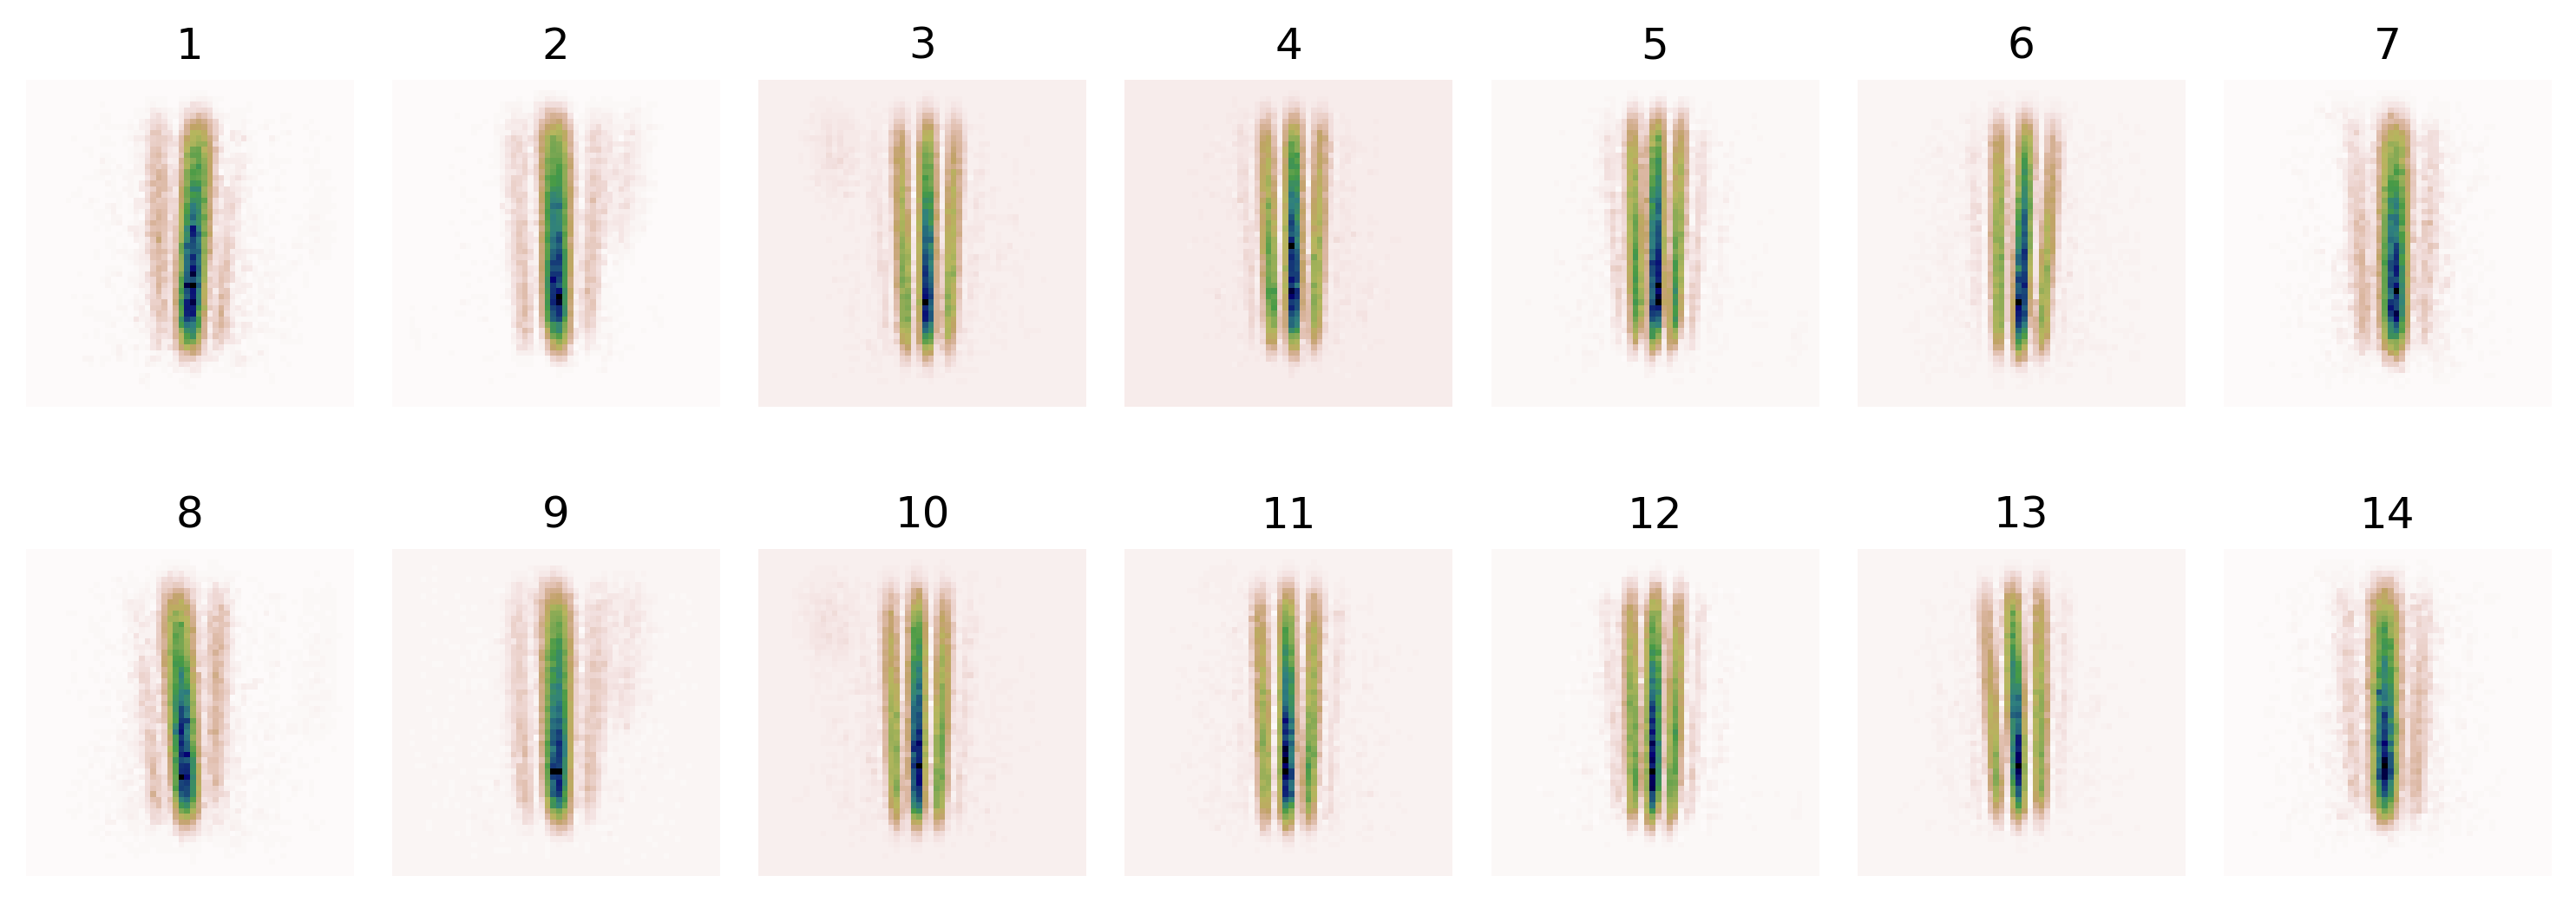

In [64]:
#-- First integrated fringes
this_iter = 0
fringes = res['hdfs_fringes'][this_iter]
visu.hdfs_show_fringes(gaps.hdfs, fringes=fringes)

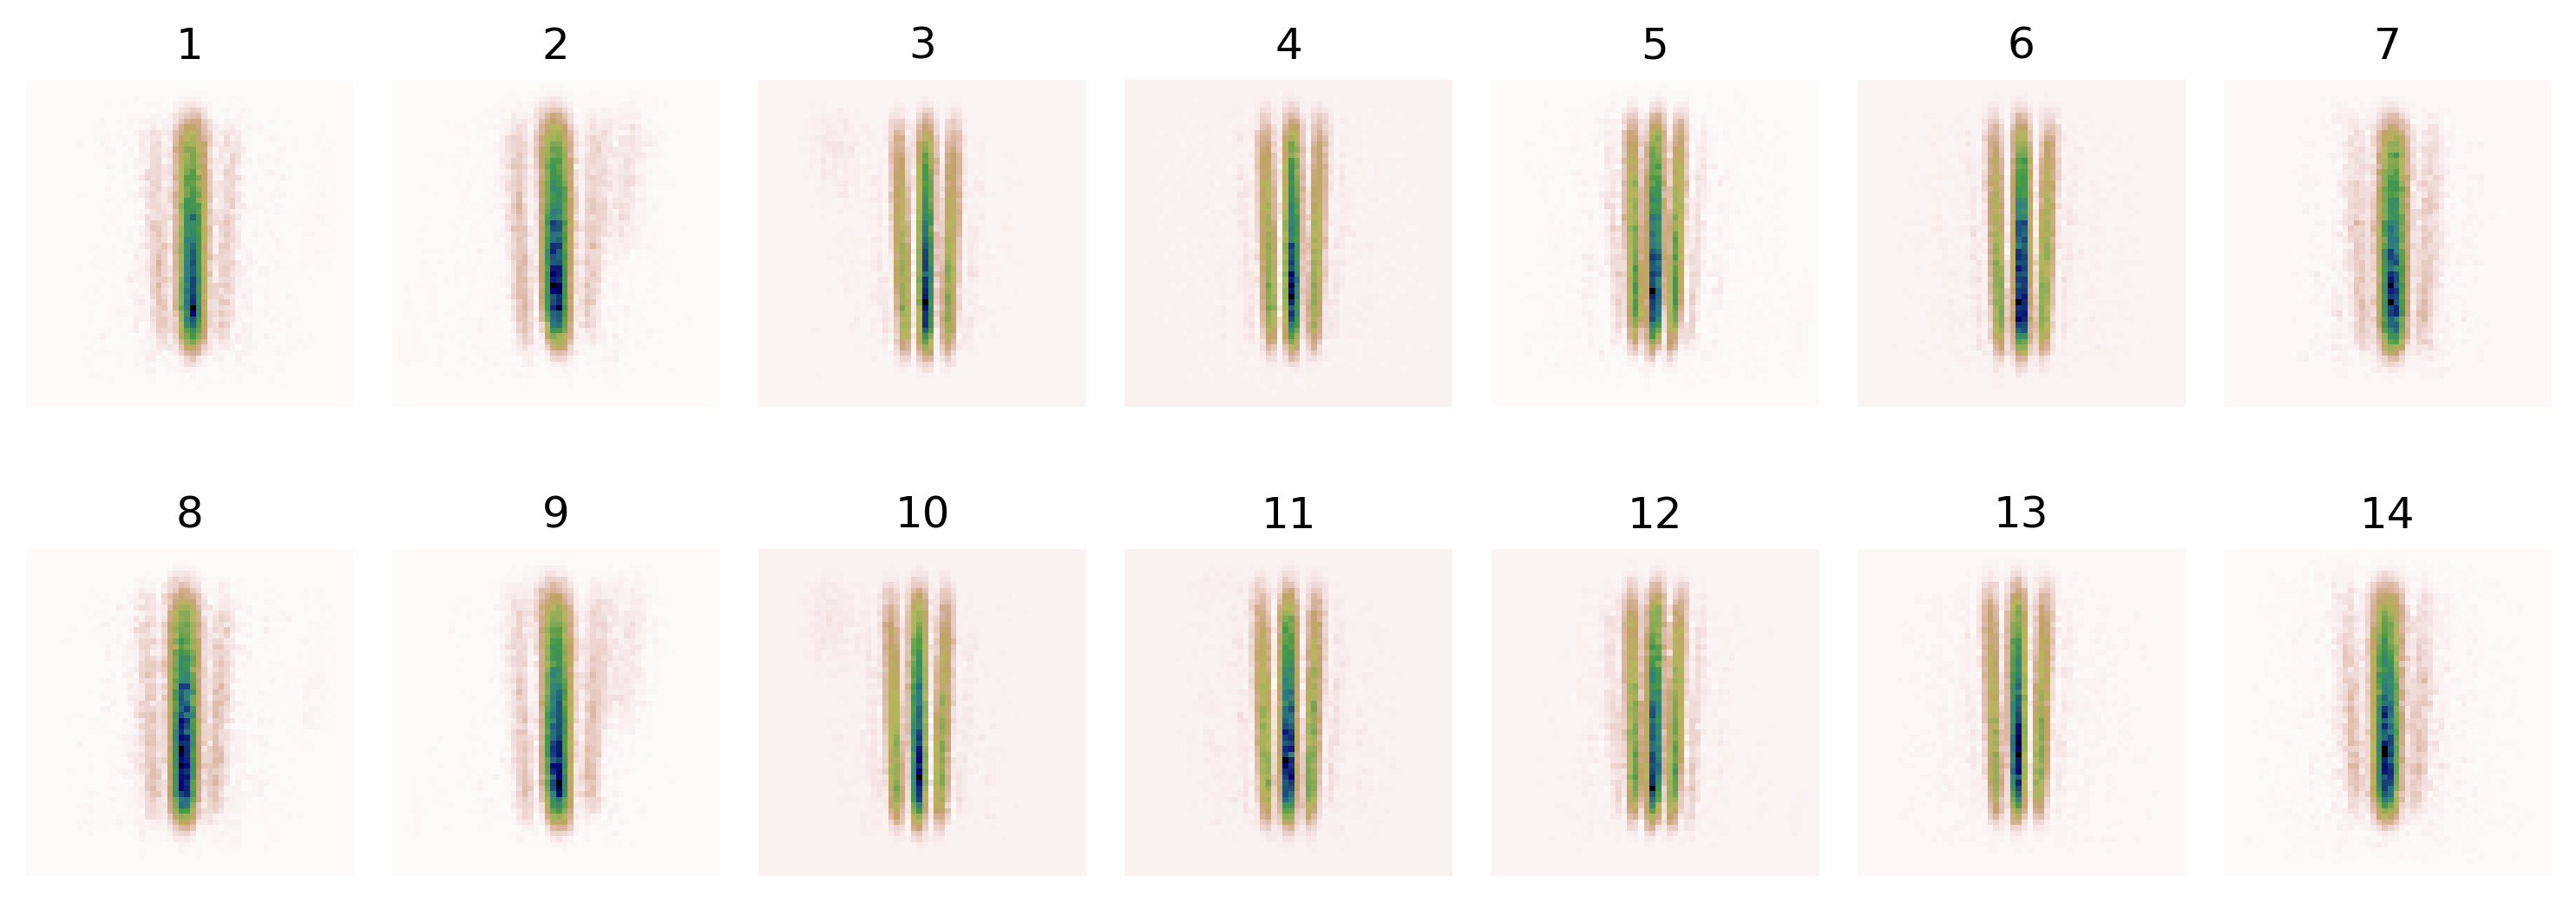

In [65]:
#-- Last integrated fringes
this_iter = -1
fringes = res['hdfs_fringes'][this_iter]
visu.hdfs_show_fringes(gaps.hdfs, fringes=fringes)